In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from ModelClass import RegressionModel
from DatasetClass import Dataset, DatasetMass
from src.helpers import pick_only_target, extract_data, pick_only_mmc

In [13]:
#Model_Name = "PatrikNet_phi_flattened_17s_20_200.keras"
Model_Name = "PatrikNet_lorentz_flattened_17s_20_180_3epochs.keras"

In [14]:
dataset_h125 = DatasetMass()
dataset_h125.load_data(file_name = "data_h125")

dataset_Ztt = DatasetMass()
dataset_Ztt.load_data(file_name = "data_mmc")


In [ ]:
#TRUE Golden Values
y_true_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_target)))
y_true_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_target)))

y_true_H125 = np.concatenate([y_true_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_target)))])
y_true_Ztt = np.concatenate([y_true_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_target)))])

In [ ]:
#MMC Predictions
y_mmc_Ztt = np.array(extract_data(dataset_Ztt.val_dataset.map(pick_only_mmc)))
y_mmc_H125 = np.array(extract_data(dataset_h125.val_dataset.map(pick_only_mmc)))

y_mmc_Ztt = np.concatenate([y_mmc_Ztt, np.array(extract_data(dataset_Ztt.dev_dataset.map(pick_only_mmc)))])
y_mmc_H125 = np.concatenate([y_mmc_H125, np.array(extract_data(dataset_h125.dev_dataset.map(pick_only_mmc)))])


2025-07-01 22:44:20.129044: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# NN Predictions
print("Predicting Ztt masses...")
model_Ztt = RegressionModel(dataset=dataset_Ztt)
model_Ztt.load(model_name=Model_Name)
y_pred_Ztt = model_Ztt.model.predict(dataset_Ztt.val_dataset.batch(10000)).squeeze()
y_pred_Ztt = np.concatenate([y_pred_Ztt, model_Ztt.model.predict(dataset_Ztt.dev_dataset.batch(10000)).squeeze()])

print("Predicting H125 masses...")
model_H125 = RegressionModel(dataset=dataset_h125)
model_H125.load(model_name=Model_Name)
y_pred_H125 = model_H125.model.predict(dataset_h125.val_dataset.batch(10000)).squeeze()
y_pred_H125 = np.concatenate([y_pred_H125, model_H125.model.predict(dataset_h125.dev_dataset.batch(10000)).squeeze()])

Predicting Ztt masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_17s_20_200.keras


I0000 00:00:1751402661.035880 1724459 service.cc:148] XLA service 0x7fbdcc005db0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751402661.035921 1724459 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-07-01 22:44:21.044600: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 2/98 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step   

I0000 00:00:1751402661.290181 1724459 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step
Predicting H125 masses...
Number of devices: 1
Model loaded from /home/ivanpa/HiggsAnalysisBc/models/PatrikNet_phi_flattened_17s_20_200.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step


total number of events: 3580676
--------------------


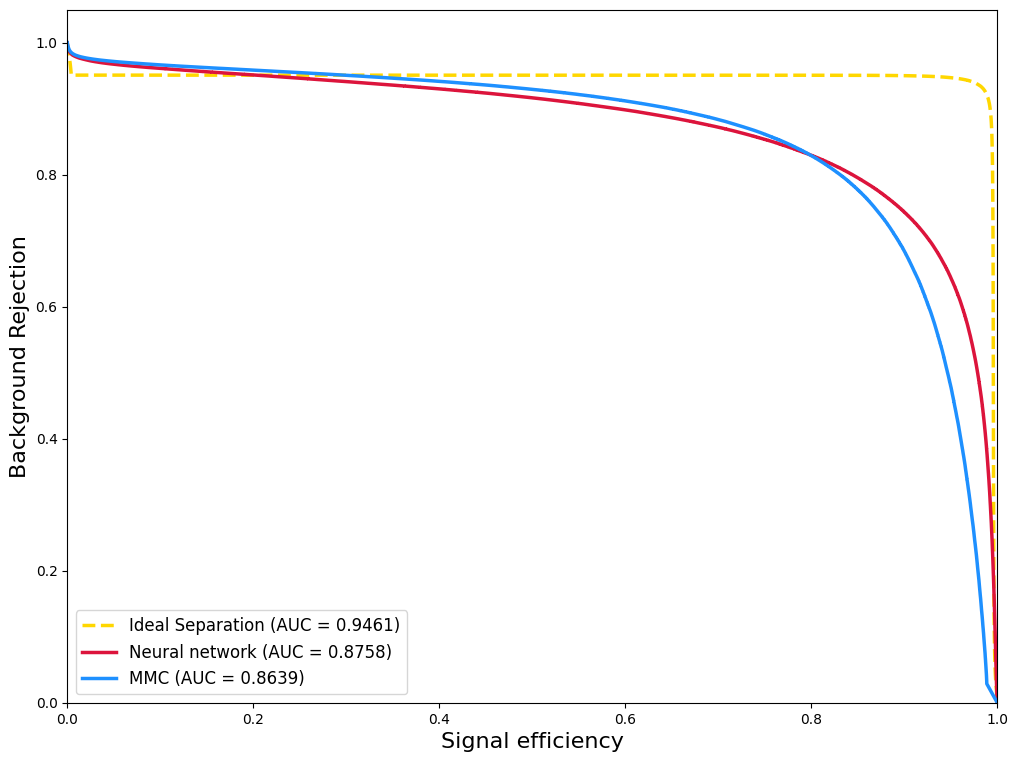


Plocha pod krivkou (AUC) pre Ideálnu separáciu: 0.9461
Plocha pod krivkou (AUC) pre Neurónovú sieť:   0.8758
Plocha pod krivkou (AUC) pre MMC:             0.8639


In [ ]:
# 2.1. Vytvorenie poľa s označeniami (labels)
#num_signal = 815460  # Počet udalostí pre signál (H125)
#num_background = 974877  # Počet udalostí pre pozadie (Ztt)
num_signal = len(y_pred_H125)  # Počet udalostí pre signál (H125)
num_background = len(y_pred_Ztt)  # Počet udalostí pre pozadie (Ztt)
labels = np.concatenate([np.ones(num_signal), np.zeros(num_background)])

# 2.2. Spojenie predikcií pre každý klasifikátor
predictions_nn = np.concatenate([y_pred_H125, y_pred_Ztt])
predictions_mmc = np.concatenate([y_mmc_H125, y_mmc_Ztt])
predictions_golden = np.concatenate([y_true_H125, y_true_Ztt])

print(f"total number of events: {len(labels)}")
print("-" * 20)

# Výpočet pre Neurónovú sieť (NN)
fpr_nn, tpr_nn, _ = roc_curve(labels, predictions_nn)
auc_nn = auc(fpr_nn, tpr_nn)

# Výpočet pre MMC
fpr_mmc, tpr_mmc, _ = roc_curve(labels, predictions_mmc)
auc_mmc = auc(fpr_mmc, tpr_mmc)

# Výpočet pre Ideálnu (Golden) krivku
fpr_golden, tpr_golden, _ = roc_curve(labels, predictions_golden)
auc_golden = auc(fpr_golden, tpr_golden)

# Prevod na "background rejection"
bkg_rejection_nn = 1. - fpr_nn
bkg_rejection_mmc = 1. - fpr_mmc
bkg_rejection_golden = 1. - fpr_golden


# Vykreslenie výsledkov
plt.figure(figsize=(12, 9))

# Krivka pre Ideálnu (Golden) separáciu
plt.plot(tpr_golden, bkg_rejection_golden, lw=2.5, color='gold', linestyle='--',
         label=f'Ideal Separation (AUC = {auc_golden:.4f})')

# Krivka pre neurónovú sieť
plt.plot(tpr_nn, bkg_rejection_nn, lw=2.5, color='crimson',
         label=f'Neural network (AUC = {auc_nn:.4f})')

# Krivka pre MMC
plt.plot(tpr_mmc, bkg_rejection_mmc, lw=2.5, color='dodgerblue',
         label=f'MMC (AUC = {auc_mmc:.4f})')


# Nastavenie grafu
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Signal efficiency', fontsize=16)
plt.ylabel('Background Rejection', fontsize=16)
#plt.title('Porovnanie ROC kriviek: NN vs. MMC vs. Ideálna separácia', fontsize=16)
plt.legend(loc="lower left", fontsize=12)
#plt.grid(True)
plt.show()

print(f"\nPlocha pod krivkou (AUC) pre Ideálnu separáciu: {auc_golden:.4f}")
print(f"Plocha pod krivkou (AUC) pre Neurónovú sieť:   {auc_nn:.4f}")
print(f"Plocha pod krivkou (AUC) pre MMC:             {auc_mmc:.4f}")


--------------------


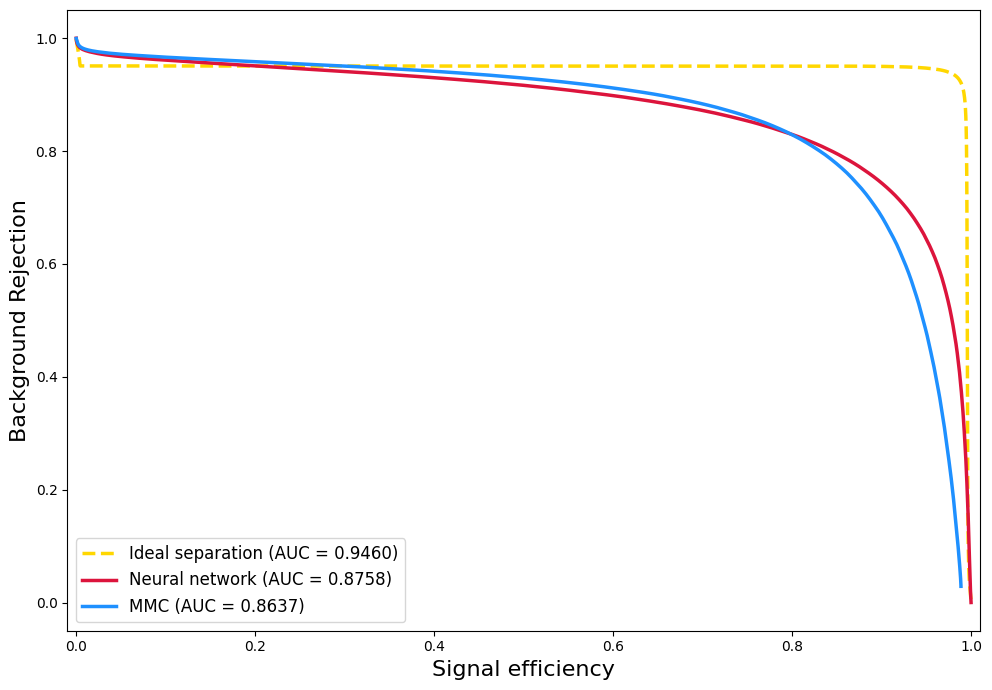


Plocha pod krivkou (AUC) pre Ideálnu separáciu: 0.9460
Plocha pod krivkou (AUC) pre Neurónovú sieť:   0.8758
Plocha pod krivkou (AUC) pre MMC:             0.8637


In [ ]:
labels = np.concatenate([np.ones(num_signal), np.zeros(num_background)])
predictions_nn = np.concatenate([y_pred_H125, y_pred_Ztt])
predictions_mmc = np.concatenate([y_mmc_H125, y_mmc_Ztt])
predictions_golden = np.concatenate([y_true_H125, y_true_Ztt])
print("-" * 20)

mass_thresholds = np.linspace(0., 500., 1000) 

nn_roc_rates = []
mmc_roc_rates = []
golden_roc_rates = []

total_signal_events = np.sum(labels == 1)
total_background_events = np.sum(labels == 0)

for threshold in mass_thresholds:
    # --- NN ---
    #True Positives
    nn_true_positive = np.sum((predictions_nn > threshold) & (labels == 1))
    #False Positives
    nn_false_positive = np.sum((predictions_nn > threshold) & (labels == 0))

    # --- MMC ---
    mmc_true_positive = np.sum((predictions_mmc > threshold) & (labels == 1))
    mmc_false_positive = np.sum((predictions_mmc > threshold) & (labels == 0))

    # --- True ---
    golden_true_positive = np.sum((predictions_golden > threshold) & (labels == 1))
    golden_false_positive = np.sum((predictions_golden > threshold) & (labels == 0))

    # (TPR, FPR) 
    nn_roc_rates.append([nn_true_positive / total_signal_events, nn_false_positive / total_background_events])
    mmc_roc_rates.append([mmc_true_positive / total_signal_events, mmc_false_positive / total_background_events])
    golden_roc_rates.append([golden_true_positive / total_signal_events, golden_false_positive / total_background_events])

nn_roc = np.array(nn_roc_rates)
mmc_roc = np.array(mmc_roc_rates)
golden_roc = np.array(golden_roc_rates)


nn_eff = nn_roc[::-1, 0]  # column 0 = TPR (efficiency)
nn_bkg_rej = 1. - nn_roc[::-1, 1]  # column 1 = FPR (background rejection)

mmc_eff = mmc_roc[::-1, 0]
mmc_bkg_rej = 1. - mmc_roc[::-1, 1]

golden_eff = golden_roc[::-1, 0]
golden_bkg_rej = 1. - golden_roc[::-1, 1]


# np.trapezoid(y, x) -> y=background rejection, x=efficiency
auc_nn = np.trapezoid(nn_bkg_rej, nn_eff)
auc_mmc = np.trapezoid(mmc_bkg_rej, mmc_eff)
auc_golden = np.trapezoid(golden_bkg_rej, golden_eff)


plt.figure(figsize=(10, 7))

plt.plot(golden_eff, golden_bkg_rej, lw=2.5, color='gold', linestyle='--', label=f'Ideal separation (AUC = {auc_golden:.4f})')
plt.plot(nn_eff, nn_bkg_rej, lw=2.5, color='crimson', label=f'Neural network (AUC = {auc_nn:.4f})')
plt.plot(mmc_eff, mmc_bkg_rej, lw=2.5, color='dodgerblue', label=f'MMC (AUC = {auc_mmc:.4f})')

plt.xlabel('Signal efficiency', fontsize=16)
plt.ylabel('Background Rejection', fontsize=16)
plt.legend(loc="lower left", fontsize=12)
#plt.grid(True)
plt.tight_layout()
plt.xlim([-0.01, 1.01])
plt.savefig('out_lorentz/roc_comparison_lorentz.png', dpi=300)
plt.show()

print(f"\nPlocha pod krivkou (AUC) pre Ideálnu separáciu: {auc_golden:.4f}")
print(f"Plocha pod krivkou (AUC) pre Neurónovú sieť:   {auc_nn:.4f}")
print(f"Plocha pod krivkou (AUC) pre MMC:             {auc_mmc:.4f}")